## 04_pancreas_baseline_entrenamiento.ipynb
 Objetivo:
 1) entrenar un experto 3D baseline para PANCREAS
 2) usar R3D-18 como arquitectura base
 3) manejar el desbalance con FocalLoss
 4) usar AMP, gradient checkpointing y early stopping
 5) guardar checkpoint, history y métricas finales

## imports

In [2]:
from pathlib import Path
import json
import time
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.models.video import r3d_18
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint

import SimpleITK as sitk
import scipy.ndimage as ndi

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

/home/luis_arcia/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## configuración global

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTS_DIR = DATA_DIR / "manifests"

MANIFEST_PATH = MANIFESTS_DIR / "manifest_pancreas.csv"
SPLIT_PATH = MANIFESTS_DIR / "split_final_pancreas.csv"

TARGET_SHAPE = (64, 64, 64)   # (D, H, W)
TARGET_SPACING = (1.0, 1.0, 1.5)

HU_MIN = -150
HU_MAX = 250

BATCH_SIZE = 2
NUM_WORKERS = 0   # más estable en WSL

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("MANIFEST_PATH:", MANIFEST_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("TARGET_SHAPE:", TARGET_SHAPE)
print("TARGET_SPACING:", TARGET_SPACING)
print("HU range:", (HU_MIN, HU_MAX))

DEVICE: cuda
MANIFEST_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/manifest_pancreas.csv
SPLIT_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/split_final_pancreas.csv
TARGET_SHAPE: (64, 64, 64)
TARGET_SPACING: (1.0, 1.0, 1.5)
HU range: (-150, 250)


## cargar manifest y split

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

df = manifest.merge(
    split_df[["case_id", "split"]],
    on="case_id",
    how="left"
)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nDistribución train:")
print(train_df["label_binary"].value_counts())

train: (392, 15)
val: (82, 15)
test: (83, 15)

Distribución train:
label_binary
0    281
1    111
Name: count, dtype: int64


## helpers de lectura y preprocesado

In [5]:
def read_ct_image(path):
    image = sitk.ReadImage(str(path))
    return image


def sanitize_hu_sitk(image, lower_bound=-1024):
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume[volume < lower_bound] = lower_bound

    clean_image = sitk.GetImageFromArray(volume)
    clean_image.SetSpacing(image.GetSpacing())
    clean_image.SetOrigin(image.GetOrigin())
    clean_image.SetDirection(image.GetDirection())
    return clean_image


def resample_image_spacing(image, out_spacing=(1.0, 1.0, 1.5), is_label=False):
    original_spacing = image.GetSpacing()   # (x, y, z)
    original_size = image.GetSize()         # (x, y, z)

    out_size = [
        int(np.round(original_size[i] * (original_spacing[i] / out_spacing[i])))
        for i in range(3)
    ]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(float(-1024))

    if is_label:
        resample.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resample.SetInterpolator(sitk.sitkLinear)

    return resample.Execute(image)


def clip_and_normalize_hu(volume, hu_min=HU_MIN, hu_max=HU_MAX):
    volume = np.clip(volume, hu_min, hu_max)
    volume = (volume - hu_min) / (hu_max - hu_min)
    volume = np.clip(volume, 0.0, 1.0)
    return volume.astype(np.float32)


def resize_volume_to_shape(volume, target_shape=TARGET_SHAPE, order=1):
    d, h, w = volume.shape
    td, th, tw = target_shape

    zoom_factors = (
        td / d,
        th / h,
        tw / w,
    )

    resized = ndi.zoom(volume, zoom=zoom_factors, order=order)
    return resized.astype(np.float32)


def preprocess_ct_from_path(
    image_path,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    hu_min=HU_MIN,
    hu_max=HU_MAX,
):
    image = read_ct_image(image_path)
    image = sanitize_hu_sitk(image, lower_bound=-1024)
    image = resample_image_spacing(image, out_spacing=target_spacing, is_label=False)

    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume = clip_and_normalize_hu(volume, hu_min=hu_min, hu_max=hu_max)
    volume = resize_volume_to_shape(volume, target_shape=target_shape, order=1)

    return volume, image

## Dataset y DataLoaders

In [ ]:
class PancreasVolumeDataset(Dataset):
    def __init__(self, df, target_spacing=TARGET_SPACING, target_shape=TARGET_SHAPE):
        self.df = df.reset_index(drop=True).copy()
        self.target_spacing = target_spacing
        self.target_shape = target_shape

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        volume, processed_image = preprocess_ct_from_path(
            row["image_path"],
            target_spacing=self.target_spacing,
            target_shape=self.target_shape,
            hu_min=HU_MIN,
            hu_max=HU_MAX,
        )

        x = torch.from_numpy(volume).unsqueeze(0)  # [1, D, H, W]
        y = torch.tensor(int(row["label_binary"]), dtype=torch.long)

        meta = {
            "case_id": row["case_id"],
            "patient_id": row["patient_id"],
            "split": row["split"],
            "image_path": row["image_path"],
            "label_str": row["label_str"],
            "processed_spacing_xyz": processed_image.GetSpacing(),
            "processed_size_xyz": processed_image.GetSize(),
        }

        return x, y, meta


def simple_collate(batch):
    xs, ys, metas = zip(*batch)
    xs = torch.stack(xs, dim=0)   # [B, 1, D, H, W]
    ys = torch.stack(ys, dim=0)   # [B]
    return xs, ys, metas


train_ds = PancreasVolumeDataset(train_df, target_spacing=TARGET_SPACING, target_shape=TARGET_SHAPE)
val_ds   = PancreasVolumeDataset(val_df, target_spacing=TARGET_SPACING, target_shape=TARGET_SHAPE)
test_ds  = PancreasVolumeDataset(test_df, target_spacing=TARGET_SPACING, target_shape=TARGET_SHAPE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

print("DataLoaders listos.")
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

DataLoaders listos.
Train size: 392
Val size: 82
Test size: 83


## configuración de entrenamiento

In [ ]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pancreas_r3d18_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HISTORY_PATH = OUTPUT_DIR / "history_pancreas_r3d18.csv"
BEST_MODEL_PATH = OUTPUT_DIR / "best_pancreas_r3d18.pt"
TEST_PRED_PATH = OUTPUT_DIR / "test_predictions_pancreas_r3d18.csv"
CONFIG_PATH = OUTPUT_DIR / "config_pancreas_r3d18.json"

NUM_CLASSES = 2
IN_CHANNELS = 1

EPOCHS = 12
LR = 1e-4
WEIGHT_DECAY = 1e-4
ACCUMULATION_STEPS = 2
GRAD_CLIP_NORM = 1.0

PATIENCE = 3
MIN_DELTA = 1e-4

USE_AMP = (DEVICE == "cuda")
USE_GRADIENT_CHECKPOINTING = True

FOCAL_GAMMA = 2.0

print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_AMP:", USE_AMP)
print("USE_GRADIENT_CHECKPOINTING:", USE_GRADIENT_CHECKPOINTING)
print("FOCAL_GAMMA:", FOCAL_GAMMA)

OUTPUT_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline
USE_AMP: True
USE_GRADIENT_CHECKPOINTING: True
FOCAL_GAMMA: 2.0


## guardar config

In [8]:
config = {
    "model_name": "R3D18",
    "num_classes": NUM_CLASSES,
    "in_channels": IN_CHANNELS,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "accumulation_steps": ACCUMULATION_STEPS,
    "grad_clip_norm": GRAD_CLIP_NORM,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
    "use_amp": USE_AMP,
    "use_gradient_checkpointing": USE_GRADIENT_CHECKPOINTING,
    "focal_gamma": FOCAL_GAMMA,
    "hu_min": HU_MIN,
    "hu_max": HU_MAX,
    "target_shape": TARGET_SHAPE,
    "target_spacing": TARGET_SPACING,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Config guardada en:", CONFIG_PATH)

Config guardada en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/config_pancreas_r3d18.json


## modelo R3D-18

In [9]:
class R3D18Binary(nn.Module):
    def __init__(self, num_classes=2, in_channels=1, use_gradient_checkpointing=True):
        super().__init__()
        self.use_gradient_checkpointing = use_gradient_checkpointing

        base = r3d_18(weights=None)

        old_conv = base.stem[0]
        new_conv = nn.Conv3d(
            in_channels=in_channels,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")
        base.stem[0] = new_conv
        base.fc = nn.Linear(base.fc.in_features, num_classes)

        self.base = base

    def _forward_features(self, x):
        x = self.base.stem(x)

        if self.training and self.use_gradient_checkpointing:
            x = checkpoint(self.base.layer1, x, use_reentrant=False)
            x = checkpoint(self.base.layer2, x, use_reentrant=False)
            x = checkpoint(self.base.layer3, x, use_reentrant=False)
            x = checkpoint(self.base.layer4, x, use_reentrant=False)
        else:
            x = self.base.layer1(x)
            x = self.base.layer2(x)
            x = self.base.layer3(x)
            x = self.base.layer4(x)

        x = self.base.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = self.base.fc(x)
        return x

## instanciar modelo

In [10]:
model = R3D18Binary(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    use_gradient_checkpointing=USE_GRADIENT_CHECKPOINTING
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model.__class__.__name__)
print(f"Parámetros totales: {n_params:,}")
print(f"Parámetros entrenables: {n_trainable:,}")

R3D18Binary
Parámetros totales: 33,148,482
Parámetros entrenables: 33,148,482


## FocalLoss

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        probs = torch.softmax(logits, dim=1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        focal_factor = (1.0 - pt) ** self.gamma

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            loss = alpha_t * focal_factor * ce_loss
        else:
            loss = focal_factor * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

## loss, optimizer, scheduler, scaler

In [12]:
class_counts = train_df["label_binary"].value_counts().sort_index()
print("class_counts:\n", class_counts)

class_weights = torch.tensor(
    [
        len(train_df) / (2.0 * class_counts[0]),
        len(train_df) / (2.0 * class_counts[1]),
    ],
    dtype=torch.float32
)

print("class_weights:", class_weights)

criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA, reduction="mean")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print("Loss, optimizer, scheduler y scaler listos.")

class_counts:
 label_binary
0    281
1    111
Name: count, dtype: int64
class_weights: tensor([0.6975, 1.7658])
Loss, optimizer, scheduler y scaler listos.


/tmp/ipykernel_23831/4132941586.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## helper de métricas

In [13]:
def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
    }

## train one epoch

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, accumulation_steps=1):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc="Train", leave=False)
    for step, (xb, yb, _) in enumerate(pbar, start=1):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if step % accumulation_steps == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * accumulation_steps

        preds = torch.argmax(logits, dim=1)
        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix({
            "loss": f"{running_loss / step:.4f}"
        })

    metrics = compute_metrics(all_targets, all_preds)
    metrics["loss"] = running_loss / len(loader)
    return metrics

## evaluate one epoch

In [15]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device, desc="Eval"):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []
    all_probs = []
    all_case_ids = []

    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb, metas in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item()

        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].detach().cpu().numpy().tolist())
        all_case_ids.extend([m["case_id"] for m in metas])

        pbar.set_postfix({
            "loss": f"{running_loss / max(1, len(all_targets)):.4f}"
        })

    metrics = compute_metrics(all_targets, all_preds)
    metrics["loss"] = running_loss / len(loader)

    extra = {
        "targets": all_targets,
        "preds": all_preds,
        "probs_pos": all_probs,
        "case_ids": all_case_ids,
    }

    return metrics, extra

## early stopping

In [16]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True

        improved = (
            score > self.best_score + self.min_delta
            if self.mode == "max"
            else score < self.best_score - self.min_delta
        )

        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

## entrenamiento principal

In [17]:
history = []
best_state = None
best_epoch = -1
best_val_f1 = -np.inf

early_stopper = EarlyStopping(
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    mode="max"
)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
        accumulation_steps=ACCUMULATION_STEPS
    )

    val_metrics, _ = evaluate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        desc="Val"
    )

    scheduler.step(val_metrics["f1_macro"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_f1_macro": train_metrics["f1_macro"],
        "train_f1_micro": train_metrics["f1_micro"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_f1_micro": val_metrics["f1_micro"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={row['train_loss']:.4f} | "
        f"train_f1_macro={row['train_f1_macro']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"val_f1_macro={row['val_f1_macro']:.4f}"
    )

    improved = early_stopper.step(val_metrics["f1_macro"])
    if improved:
        best_val_f1 = val_metrics["f1_macro"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, BEST_MODEL_PATH)
        print(f"Nuevo mejor modelo guardado en epoch {epoch} -> {BEST_MODEL_PATH}")

    if early_stopper.should_stop:
        print(f"Early stopping activado en epoch {epoch}")
        break

elapsed = time.time() - start_time
print(f"\nTiempo total de entrenamiento: {elapsed/60:.2f} min")
print("Best epoch:", best_epoch)
print("Best val_f1_macro:", round(best_val_f1, 4))


Epoch 1/12


train_loss=0.2527 | train_f1_macro=0.4910 | val_loss=0.2017 | val_f1_macro=0.4392
Nuevo mejor modelo guardado en epoch 1 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/best_pancreas_r3d18.pt

Epoch 2/12


train_loss=0.2476 | train_f1_macro=0.5324 | val_loss=0.1814 | val_f1_macro=0.3735

Epoch 3/12


train_loss=0.1897 | train_f1_macro=0.5972 | val_loss=0.2367 | val_f1_macro=0.4947
Nuevo mejor modelo guardado en epoch 3 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/best_pancreas_r3d18.pt

Epoch 4/12


train_loss=0.1837 | train_f1_macro=0.6948 | val_loss=0.8307 | val_f1_macro=0.4573

Epoch 5/12


...

train_loss=0.0032 | train_f1_macro=0.9969 | val_loss=1.1911 | val_f1_macro=0.5341

Epoch 9/12


train_loss=0.0029 | train_f1_macro=0.9937 | val_loss=1.0281 | val_f1_macro=0.5693
Nuevo mejor modelo guardado en epoch 9 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/best_pancreas_r3d18.pt

Epoch 10/12


train_loss=0.0002 | train_f1_macro=1.0000 | val_loss=1.1346 | val_f1_macro=0.5426

Epoch 11/12


train_loss=0.0000 | train_f1_macro=1.0000 | val_loss=1.0293 | val_f1_macro=0.5823
Nuevo mejor modelo guardado en epoch 11 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/best_pancreas_r3d18.pt

Epoch 12/12


train_loss=0.0000 | train_f1_macro=1.0000 | val_loss=0.9231 | val_f1_macro=0.5729

Tiempo total de entrenamiento: 196.43 min
Best epoch: 11
Best val_f1_macro: 0.5823


## guardar history

In [18]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("History guardado en:", HISTORY_PATH)
display(history_df.tail())

History guardado en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/history_pancreas_r3d18.csv


,epoch,train_loss,train_acc,train_f1_macro,train_f1_micro,val_loss,val_acc,val_f1_macro,val_f1_micro,lr
7,8,0.003170,0.997449,0.996867,0.997449,1.191091,0.707317,0.534091,0.707317,0.0001
8,9,0.002861,0.994898,0.993681,0.994898,1.028078,0.756098,0.569328,0.756098,0.0001
9,10,0.000213,1.000000,1.000000,1.000000,1.134578,0.719512,0.542566,0.719512,0.0001
10,11,0.000034,1.000000,1.000000,1.000000,1.029272,0.719512,0.582281,0.719512,0.0001
11,12,0.000037,1.000000,1.000000,1.000000,0.923097,0.707317,0.572917,0.707317,0.0001


## curvas

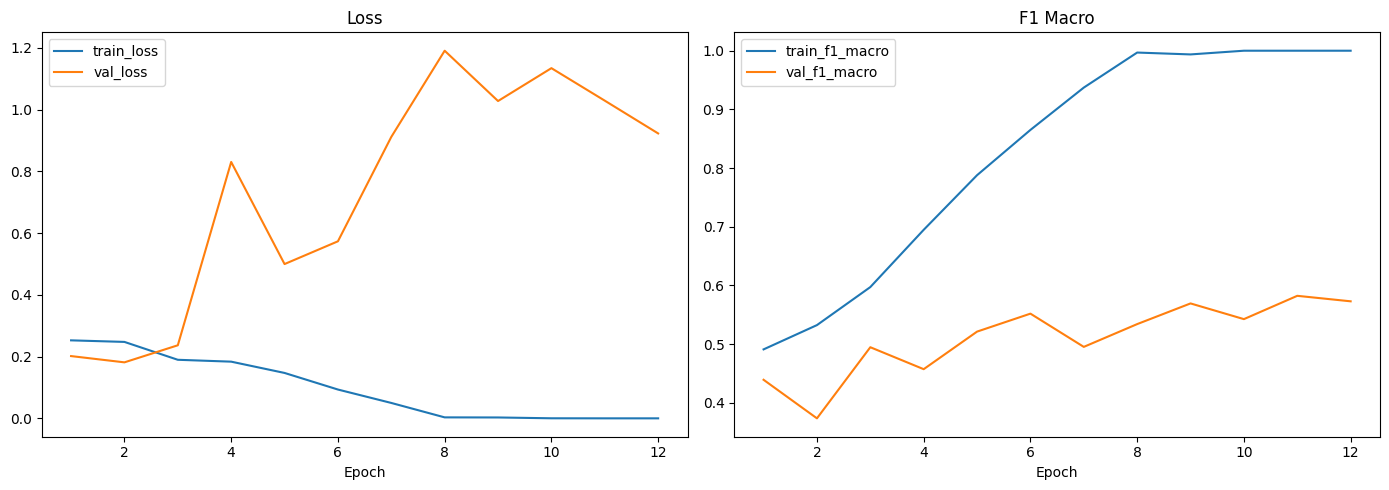

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("F1 Macro")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## cargar mejor checkpoint

In [20]:
best_state = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(best_state)
print("Mejor checkpoint cargado.")

Mejor checkpoint cargado.


## evaluación final en validación

In [21]:
val_metrics, val_extra = evaluate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Val final"
)

print("Resultados en validación:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

Resultados en validación:
acc: 0.7195
f1_macro: 0.5823
f1_micro: 0.7195
loss: 1.0293


## evaluación final en test

In [22]:
test_metrics, test_extra = evaluate_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Test final"
)

print("Resultados en test:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Resultados en test:
acc: 0.7108
f1_macro: 0.5354
f1_micro: 0.7108
loss: 0.6999


## classification report

In [23]:
print(
    classification_report(
        test_extra["targets"],
        test_extra["preds"],
        target_names=["non-PDAC", "PDAC"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    non-PDAC       0.73      0.93      0.82        59
        PDAC       0.50      0.17      0.25        24

    accuracy                           0.71        83
   macro avg       0.62      0.55      0.54        83
weighted avg       0.67      0.71      0.66        83



## matriz de confusión

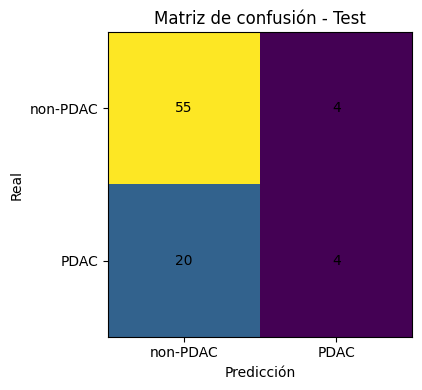

In [24]:
cm = confusion_matrix(test_extra["targets"], test_extra["preds"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title("Matriz de confusión - Test")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["non-PDAC", "PDAC"])
ax.set_yticklabels(["non-PDAC", "PDAC"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## guardar predicciones

In [25]:
test_pred_df = pd.DataFrame({
    "case_id": test_extra["case_ids"],
    "y_true": test_extra["targets"],
    "y_pred": test_extra["preds"],
    "prob_pdac": test_extra["probs_pos"],
})

test_pred_df.to_csv(TEST_PRED_PATH, index=False)
print("Predicciones de test guardadas en:", TEST_PRED_PATH)

display(test_pred_df.head())

Predicciones de test guardadas en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/test_predictions_pancreas_r3d18.csv


,case_id,y_true,y_pred,prob_pdac
0,100007_00001,0,0,0.043121
1,100011_00001,1,0,0.149292
2,100013_00001,0,0,0.163818
3,100019_00001,0,0,0.233154
4,100029_00001,0,0,0.218140


## resumen final

In [26]:
print("Resumen baseline PANCREAS - R3D18")
print("-" * 40)
print("Best epoch:", best_epoch)
print("Best val_f1_macro:", round(best_val_f1, 4))
print("Test loss:", round(test_metrics["loss"], 4))
print("Test acc:", round(test_metrics["acc"], 4))
print("Test f1_macro:", round(test_metrics["f1_macro"], 4))
print("Test f1_micro:", round(test_metrics["f1_micro"], 4))
print("Checkpoint:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)
print("Predicciones:", TEST_PRED_PATH)

Resumen baseline PANCREAS - R3D18
----------------------------------------
Best epoch: 11
Best val_f1_macro: 0.5823
Test loss: 0.6999
Test acc: 0.7108
Test f1_macro: 0.5354
Test f1_micro: 0.7108
Checkpoint: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/best_pancreas_r3d18.pt
History: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/history_pancreas_r3d18.csv
Predicciones: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/test_predictions_pancreas_r3d18.csv


## prueba tresshold


In [27]:
# Reevaluar con el mejor checkpoint para asegurar que val_extra y test_extra estén actualizados
val_metrics, val_extra = evaluate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Val threshold tuning"
)

test_metrics, test_extra = evaluate_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Test threshold tuning"
)

print("Validación base:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nTest base:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Validación base:
acc: 0.7195
f1_macro: 0.5823
f1_micro: 0.7195
loss: 1.0293

Test base:
acc: 0.7108
f1_macro: 0.5354
f1_micro: 0.7108
loss: 0.6999


In [28]:
def evaluate_threshold(y_true, prob_pos, threshold):
    y_pred = (np.array(prob_pos) >= threshold).astype(int)

    metrics = {
        "threshold": float(threshold),
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_non_pdac": f1_score(y_true, y_pred, pos_label=0, average="binary", zero_division=0),
        "f1_pdac": f1_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
    }
    return metrics, y_pred

In [29]:
threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

val_rows = []
for thr in threshold_grid:
    metrics_thr, _ = evaluate_threshold(
        y_true=val_extra["targets"],
        prob_pos=val_extra["probs_pos"],
        threshold=thr
    )
    val_rows.append(metrics_thr)

threshold_results_df = pd.DataFrame(val_rows)

threshold_ranked_df = threshold_results_df.sort_values(
    by=["f1_macro", "f1_pdac", "f1_non_pdac"],
    ascending=False
).reset_index(drop=True)

threshold_plot_df = threshold_results_df.sort_values("threshold").reset_index(drop=True)

display(threshold_ranked_df.head(10))

best_threshold = float(threshold_ranked_df.loc[0, "threshold"])
best_val_f1_macro_thr = float(threshold_ranked_df.loc[0, "f1_macro"])

print("Mejor threshold encontrado en validación:", best_threshold)
print("Mejor val_f1_macro con threshold tuning:", round(best_val_f1_macro_thr, 4))

,threshold,acc,f1_macro,f1_micro,f1_non_pdac,f1_pdac
0,0.47,0.719512,0.582281,0.719512,0.821705,0.342857
1,0.48,0.719512,0.582281,0.719512,0.821705,0.342857
2,0.49,0.719512,0.582281,0.719512,0.821705,0.342857
3,0.50,0.719512,0.582281,0.719512,0.821705,0.342857
4,0.51,0.719512,0.582281,0.719512,0.821705,0.342857
5,0.52,0.719512,0.582281,0.719512,0.821705,0.342857
6,0.60,0.731707,0.572917,0.731707,0.833333,0.312500
7,0.45,0.707317,0.572917,0.707317,0.812500,0.333333
8,0.46,0.707317,0.572917,0.707317,0.812500,0.333333
9,0.71,0.756098,0.569328,0.756098,0.852941,0.285714


Mejor threshold encontrado en validación: 0.47
Mejor val_f1_macro con threshold tuning: 0.5823


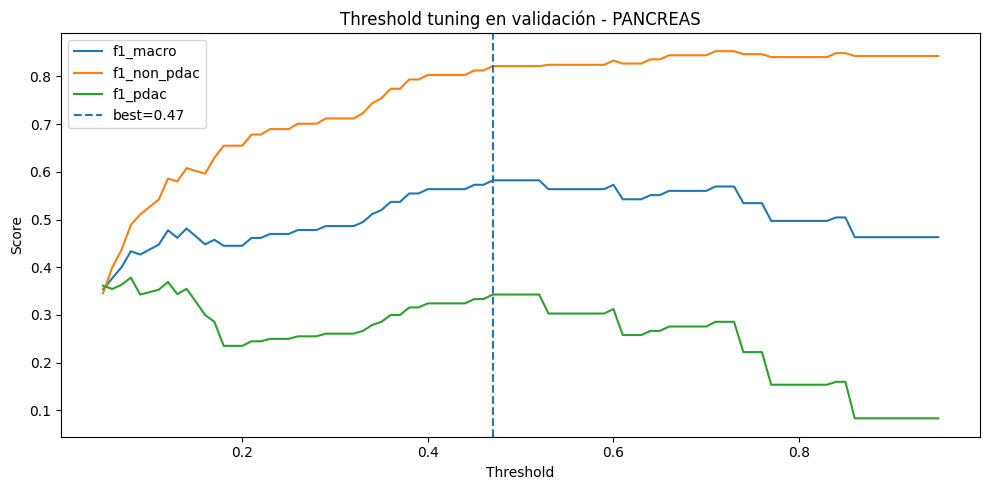

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["f1_macro"], label="f1_macro")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["f1_non_pdac"], label="f1_non_pdac")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["f1_pdac"], label="f1_pdac")
plt.axvline(best_threshold, linestyle="--", label=f"best={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning en validación - PANCREAS")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
test_metrics_thr, test_pred_thr = evaluate_threshold(
    y_true=test_extra["targets"],
    prob_pos=test_extra["probs_pos"],
    threshold=best_threshold
)

print("Resultados en test con threshold tuning:")
for k, v in test_metrics_thr.items():
    if k != "threshold":
        print(f"{k}: {v:.4f}")
print("threshold usado:", best_threshold)

Resultados en test con threshold tuning:
acc: 0.6867
f1_macro: 0.5192
f1_micro: 0.6867
f1_non_pdac: 0.8030
f1_pdac: 0.2353
threshold usado: 0.47


In [32]:
print(
    classification_report(
        test_extra["targets"],
        test_pred_thr,
        target_names=["non-PDAC", "PDAC"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    non-PDAC       0.73      0.90      0.80        59
        PDAC       0.40      0.17      0.24        24

    accuracy                           0.69        83
   macro avg       0.56      0.53      0.52        83
weighted avg       0.63      0.69      0.64        83



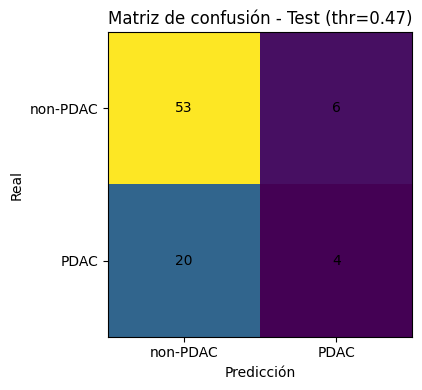

In [33]:
cm_thr = confusion_matrix(test_extra["targets"], test_pred_thr)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_thr)
ax.set_title(f"Matriz de confusión - Test (thr={best_threshold:.2f})")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["non-PDAC", "PDAC"])
ax.set_yticklabels(["non-PDAC", "PDAC"])

for i in range(cm_thr.shape[0]):
    for j in range(cm_thr.shape[1]):
        ax.text(j, i, cm_thr[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [34]:
TEST_PRED_THR_PATH = OUTPUT_DIR / "test_predictions_pancreas_r3d18_threshold_tuned.csv"
THRESHOLD_SWEEP_PATH = OUTPUT_DIR / "val_threshold_sweep_pancreas_r3d18.csv"

test_pred_thr_df = pd.DataFrame({
    "case_id": test_extra["case_ids"],
    "y_true": test_extra["targets"],
    "prob_pdac": test_extra["probs_pos"],
    "y_pred_threshold_tuned": test_pred_thr,
    "threshold_used": best_threshold,
})

test_pred_thr_df.to_csv(TEST_PRED_THR_PATH, index=False)
threshold_results_df.to_csv(THRESHOLD_SWEEP_PATH, index=False)

print("Guardado:")
print(" -", TEST_PRED_THR_PATH)
print(" -", THRESHOLD_SWEEP_PATH)

display(test_pred_thr_df.head())

Guardado:
 - /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/test_predictions_pancreas_r3d18_threshold_tuned.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/val_threshold_sweep_pancreas_r3d18.csv


,case_id,y_true,prob_pdac,y_pred_threshold_tuned,threshold_used
0,100007_00001,0,0.043121,0,0.47
1,100011_00001,1,0.149292,0,0.47
2,100013_00001,0,0.163818,0,0.47
3,100019_00001,0,0.233154,0,0.47
4,100029_00001,0,0.218140,0,0.47


In [35]:
comparison_df = pd.DataFrame([
    {
        "version": "base_argmax",
        "acc": test_metrics["acc"],
        "f1_macro": test_metrics["f1_macro"],
        "f1_micro": test_metrics["f1_micro"],
    },
    {
        "version": "threshold_tuned",
        "acc": test_metrics_thr["acc"],
        "f1_macro": test_metrics_thr["f1_macro"],
        "f1_micro": test_metrics_thr["f1_micro"],
    }
])

display(comparison_df)

,version,acc,f1_macro,f1_micro
0,base_argmax,0.710843,0.535448,0.710843
1,threshold_tuned,0.686747,0.519162,0.686747


In [36]:
FINAL_THRESHOLD = best_threshold
FINAL_TEST_ACC = test_metrics_thr["acc"]
FINAL_TEST_F1_MACRO = test_metrics_thr["f1_macro"]
FINAL_TEST_F1_MICRO = test_metrics_thr["f1_micro"]
FINAL_TEST_F1_NON_PDAC = test_metrics_thr["f1_non_pdac"]
FINAL_TEST_F1_PDAC = test_metrics_thr["f1_pdac"]

print("Resultado oficial provisional - PANCREAS")
print("-" * 45)
print(f"threshold final: {FINAL_THRESHOLD:.2f}")
print(f"test_acc: {FINAL_TEST_ACC:.4f}")
print(f"test_f1_macro: {FINAL_TEST_F1_MACRO:.4f}")
print(f"test_f1_micro: {FINAL_TEST_F1_MICRO:.4f}")
print(f"test_f1_non_pdac: {FINAL_TEST_F1_NON_PDAC:.4f}")
print(f"test_f1_pdac: {FINAL_TEST_F1_PDAC:.4f}")

Resultado oficial provisional - PANCREAS
---------------------------------------------
threshold final: 0.47
test_acc: 0.6867
test_f1_macro: 0.5192
test_f1_micro: 0.6867
test_f1_non_pdac: 0.8030
test_f1_pdac: 0.2353


In [37]:
FINAL_SUMMARY_PATH = OUTPUT_DIR / "final_summary_pancreas_r3d18.csv"

final_summary_df = pd.DataFrame([{
    "model_name": "R3D18",
    "threshold_final": float(FINAL_THRESHOLD),
    "test_acc": float(FINAL_TEST_ACC),
    "test_f1_macro": float(FINAL_TEST_F1_MACRO),
    "test_f1_micro": float(FINAL_TEST_F1_MICRO),
    "test_f1_non_pdac": float(FINAL_TEST_F1_NON_PDAC),
    "test_f1_pdac": float(FINAL_TEST_F1_PDAC),
}])

final_summary_df.to_csv(FINAL_SUMMARY_PATH, index=False)
print("Resumen final guardado en:", FINAL_SUMMARY_PATH)
display(final_summary_df)

Resumen final guardado en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/pancreas_r3d18_baseline/final_summary_pancreas_r3d18.csv


,model_name,threshold_final,test_acc,test_f1_macro,test_f1_micro,test_f1_non_pdac,test_f1_pdac
0,R3D18,0.47,0.686747,0.519162,0.686747,0.80303,0.235294
